In [8]:
path = 'dataset path'

In [12]:
import tensorflow as tf
import os
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [12]:
IMG_HEIGHT = 300
IMG_WIDTH = 300
BATCH_SIZE = 32

In [14]:
data_dir = os.path.join(path, 'Herbify-Dataset')

train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

print("Training dataset created successfully.")
print("Validation dataset created successfully.")

Found 6250 files belonging to 92 classes.
Using 5000 files for training.


2025-12-08 10:48:28.041703: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-12-08 10:48:28.042192: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-12-08 10:48:28.042199: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-12-08 10:48:28.042699: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-08 10:48:28.043380: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 6250 files belonging to 92 classes.
Using 1250 files for validation.
Training dataset created successfully.
Validation dataset created successfully.


In [15]:
class_names=train_ds.class_names
class_names

['Allium cepa (Onion)',
 'Aloe barbadensis miller (Aloevera)',
 'Alpinia Galanga (Rasna)',
 'Amaranthus Viridis (Arive-Dantu)',
 'Andrographis paniculata (Nelavembu)',
 'Annona squamosa (Seethapala)',
 'Artocarpus heterophyllus (Jackfruit)',
 'Azadirachta indica (Neem)',
 'Bacopa monnieri (Bhrami)',
 'Bambusa vulgaris (Bamboo)',
 'Basella alba (Malabar Spinach)',
 'Brassica Juncea (Indian Mustard)',
 'Brassica oleracea (Kohlrabi)',
 'Calotropis gigantea (Crown flower_Ekka)',
 'Capsicum annuum (Chilly)',
 'Cardiospermum halicacabum (Balloon Vine)',
 'Carica papaya (Papaya)',
 'Carissa Carandas (Karanda)',
 'Catharanthus roseus (Catharanthus)',
 'Chamaecostus cuspidatus (Insulin)',
 'Cinnamomum camphora (Camphor)',
 'Citrus limon (Lemon)',
 'Citrus medica (herelikai)',
 'Coffea arabica (Coffee)',
 'Coleus amboinicus (Mexican mint_Doddpathre)',
 'Colocasia esculenta (Taro)',
 'Coriandrum sativum (Coriander)',
 'Cucurbita (Pumpkin)',
 'Curcuma longa (Turmeric)',
 'Cymbopogon (Lemongrass)',

In [18]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y),num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y),num_parallel_calls=AUTOTUNE)

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets preprocessed and optimized for performance.")

Datasets preprocessed and optimized for performance.


In [20]:
base_model=EfficientNetV2B3(include_top=False,weights='imagenet',input_shape=(300, 300, 3))
base_model.trainable=False
feature_extractor=Sequential([
    base_model,
    GlobalAveragePooling2D()
])

In [21]:
train_features = []
train_labels_list = []

for images, labels in train_ds:
    features = feature_extractor.predict(images)
    train_features.append(features)
    train_labels_list.append(labels.numpy())

train_features = np.concatenate(train_features)
train_labels = np.concatenate(train_labels_list)

print("Training features extracted:", train_features.shape)

2025-12-08 10:48:32.244822: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2025-12-08 10:48:32.404879: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 847ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

2025-12-08 10:50:35.440205: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Training features extracted: (5000, 1536)


2025-12-08 10:50:40.037393: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [22]:
val_features = []
val_labels_list = []

for images, labels in val_ds:
    features = feature_extractor.predict(images,verbose=0)
    val_features.append(features)
    val_labels_list.append(labels.numpy())

val_features = np.concatenate(val_features)
val_labels = np.concatenate(val_labels_list)

print("Validation features extracted:", val_features.shape)

Validation features extracted: (1250, 1536)


2025-12-08 10:51:11.913486: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [23]:
pca=PCA(n_components=1024)
x_train=pca.fit_transform(train_features)
x_val=pca.transform(val_features)

In [24]:
svm_model=SVC(kernel='rbf',C=10,gamma='scale')
svm_model.fit(x_train,train_labels)
print("SVM model trained successfully.")

SVM model trained successfully.


In [25]:
pred=svm_model.predict(x_val)
acc=accuracy_score(val_labels,pred)
print("Accuracy:", acc*100)

Accuracy: 95.92


In [62]:
IMG_SIZE = (300, 300)

def classify_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)  
    img_array = np.expand_dims(img_array, axis=0)
    features = feature_extractor.predict(img_array, verbose=0)  
    flat_pca = pca.transform(features)
    pred = svm_model.predict(flat_pca)[0]
    display_image(img_path)
    return class_names[pred]

In [64]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
def display_image(file_path, title="Image", hide_axis=True):
    try:
        img = mpimg.imread(file_path)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        if title:
            plt.title(title)
        if hide_axis:
            plt.axis('off')
        plt.show()
    except FileNotFoundError:
        print(f"Error: The file at '{file_path}' was not found.")
    except Exception as e:
        print(f"An error occurred: {e}")

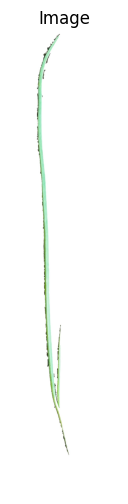

'Allium cepa (Onion)'

In [82]:
classify_image("/Users/sriramcharannalla/Downloads/testImages/onion.jpg")

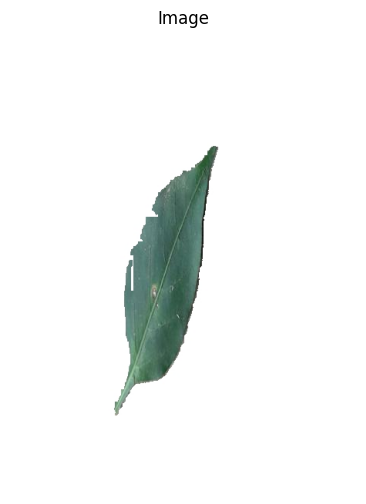

'Capsicum annuum (Chilly)'

In [68]:
classify_image("/Users/sriramcharannalla/Downloads/testImages/capsicum.jpg")

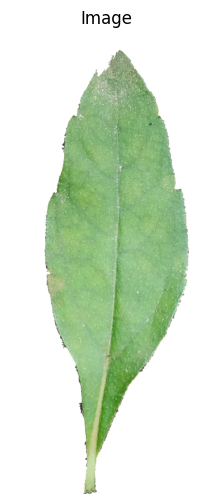

'Eclipta prostrata (Bringaraja)'

In [70]:
classify_image("/Users/sriramcharannalla/Downloads/testImages/bringraja.jpg")

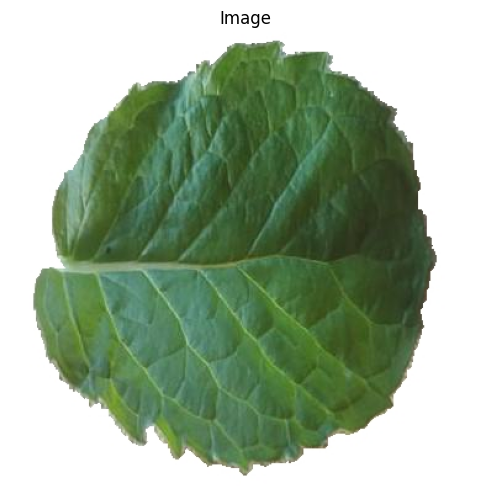

'Mentha (Mint)'

In [72]:
classify_image("/Users/sriramcharannalla/Downloads/testImages/mint.jpg")

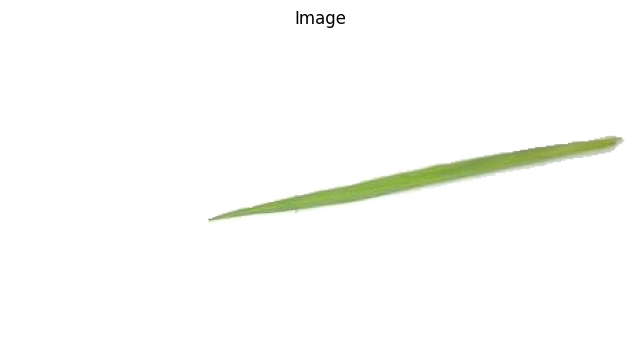

'Cymbopogon (Lemongrass)'

In [74]:
classify_image("/Users/sriramcharannalla/Downloads/testImages/lemongrass.jpg")

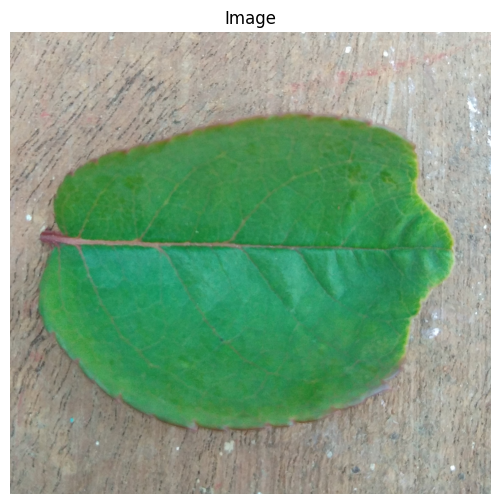

'Rosa rubiginosa (Rose)'

In [76]:
classify_image("/Users/sriramcharannalla/Downloads/testImages/rose.jpg")

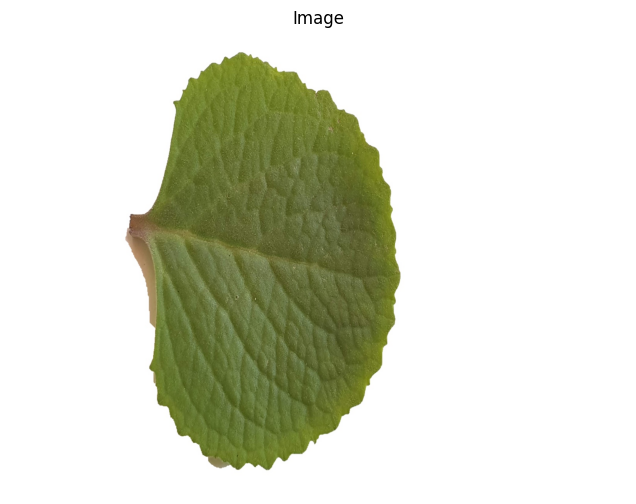

'Plectranthus Amboinicus (Mexican Mint)'

In [78]:
classify_image("/Users/sriramcharannalla/Downloads/testImages/mexicanmint.jpg")

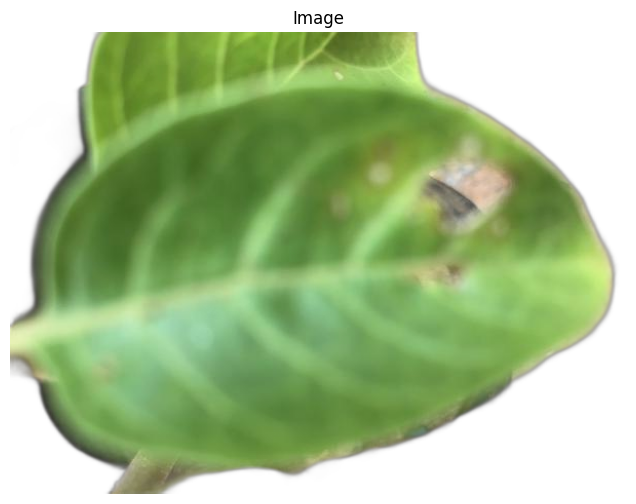

'Withania somnifera(Ashwagandha)'

In [80]:
classify_image("/Users/sriramcharannalla/Downloads/testImages/ashwagandha.png")

In [37]:
import joblib
import json
import shutil
os.makedirs("herb_model", exist_ok=True)
joblib.dump(svm_model, "herb_model/svm_model.pkl")
joblib.dump(pca, "herb_model/pca.pkl")
feature_extractor.save("herb_model/feature_extractor.keras")
with open("herb_model/class_names.json", "w") as f:
    json.dump(class_names, f)
shutil.make_archive("herb_model", 'zip', "herb_model")

'/Users/sriramcharannalla/Downloads/herb_model.zip'

In [6]:
print(tf.__version__)

2.16.2


In [10]:
print(keras.__version__)

3.12.0


In [14]:
print(np.__version__)

1.26.4


In [22]:
print(sklearn.__version__)

1.7.2


In [20]:
import sklearn